In [2]:
# --- Cell 1: imports, paths, small utils ---
from pathlib import Path
import json
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt

RES_DIR = Path("./results")

# For consistent ordering in plots
MOD_ORDER  = ["visual", "proprioceptive", "openloop"]
SESS_ORDER = ["pre", "post1"]
GRP_ORDER  = ["EC", "EO-", "EO+"]

PAL = {
    "visual":        "#1f77b4",
    "proprioceptive":"#ff7f0e",
    "openloop":      "#2ca02c",
}

def _load_cp(level:int):
    """Load idata + meta for CP{level}."""
    mdir = RES_DIR / f"CP{level}"
    idata = az.from_netcdf(mdir / "posterior.nc")
    meta  = json.loads((mdir / "meta.json").read_text())
    return idata, meta

def _title_for(level:int) -> str:
    return f"CP{level}"

In [3]:
# --- Cell 2: functions for μ (means) ---

# ---------- design-row creation that matches your token strings ----------
def _token_holds(token: str, sess: str|None, mod: str|None, grp: str|None) -> bool:
    """
    token looks like: 's@post1', 'm@openloop', 'g@EO-', or interactions joined by '*'
    Returns True iff all pieces match the requested cell (sess, mod, grp).
    """
    for piece in token.split("*"):
        k, val = piece.split("@", 1)
        if k == "s":
            if sess is None or sess != val:
                return False
        elif k == "m":
            if mod is None or mod != val:
                return False
        elif k == "g":
            if grp is None or grp != val:
                return False
        else:
            return False
    return True

def _row_for_cell(beta_names: list[str], sess: str|None, mod: str|None, grp: str|None) -> np.ndarray:
    """One-hot row for your treatment-coded design given the cell."""
    return np.array([1.0 if _token_holds(tok, sess, mod, grp) else 0.0 for tok in beta_names], dtype=float)

# ---------- posterior draw access ----------
def _post_alpha_beta_mu(idata: az.InferenceData):
    post = idata.posterior
    # (chains, draws) -> flatten
    alpha = post["alpha"].values.reshape(-1)                       # (S,)
    if "beta_mu" in post:
        B = post["beta_mu"].values                                 # (chain, draw, Kmu)
        beta = B.reshape(-1, B.shape[-1])                          # (S, Kmu)
    else:
        # Kmu == 0 case (intercept-only)
        beta = np.zeros((alpha.size, 0), dtype=float)
    return alpha, beta

# ---------- summarize helpers ----------
def _hdi(x: np.ndarray, prob=0.95):
    lo, hi = az.hdi(x, hdi_prob=prob)
    return float(lo), float(hi)

def _summarize_draws(draws: np.ndarray, prob=0.95) -> dict:
    lo, hi = _hdi(draws, prob)
    return dict(mean=float(np.mean(draws)),
                hdi_low=lo,
                hdi_high=hi,
                sd=float(np.std(draws, ddof=0)))

# ---------- per-cell μ draws ----------
def posterior_mu_draws_cell(idata: az.InferenceData, meta: dict,
                            sess: str, mod: str, grp: str|None):
    alpha, beta = _post_alpha_beta_mu(idata)
    beta_names = meta["beta_mu_names"]        # exact strings from meta.json

    if beta.shape[1] != len(beta_names):
        raise ValueError(f"beta_mu dimension ({beta.shape[1]}) != len(beta_mu_names) ({len(beta_names)})")

    x = _row_for_cell(beta_names, sess, mod, grp)                  # (Kmu,)
    # vectorized across draws: α + β·x
    return alpha + beta.dot(x)

# ---------- tables ----------
def table_cp4_mu(prob=0.95):
    """CP4 has Session × Modality (no group)."""
    idata, meta = _load_cp(4)
    sess_lvls = meta["labels"]["session"]
    mod_lvls  = meta["labels"]["modality"]

    ses  = [s for s in SESS_ORDER if s in sess_lvls]
    mods = [m for m in MOD_ORDER  if m in mod_lvls]

    rows = []
    for s in ses:
        for m in mods:
            mu = posterior_mu_draws_cell(idata, meta, sess=s, mod=m, grp=None)
            rows.append(dict(session=s, modality=m, **_summarize_draws(mu, prob)))
    df = pd.DataFrame(rows)

    # Δ(Post1-Pre) per modality
    drows = []
    for m in mods:
        pre  = df[(df.session=="pre")  & (df.modality==m)].iloc[0]["mean"]
        po1  = df[(df.session=="post1")& (df.modality==m)].iloc[0]["mean"]
        d    = po1 - pre
        # for display CI we use the actual difference of draws
        ddraws = posterior_mu_draws_cell(idata, meta, "post1", m, None) \
                 - posterior_mu_draws_cell(idata, meta, "pre",   m, None)
        drows.append(dict(modality=m, **_summarize_draws(ddraws, prob)))
    ddf = pd.DataFrame(drows)
    return df, ddf

def table_cp7_or_cp8_mu(level:int, prob=0.95):
    """CP7/CP8 have Session × Modality × Group."""
    assert level in (7,8)
    idata, meta = _load_cp(level)
    sess_lvls = meta["labels"]["session"]
    mod_lvls  = meta["labels"]["modality"]
    grp_lvls  = meta["labels"]["group"]

    ses  = [s for s in SESS_ORDER if s in sess_lvls]
    mods = [m for m in MOD_ORDER  if m in mod_lvls]
    grps = [g for g in GRP_ORDER  if g in grp_lvls]

    rows = []
    for g in grps:
        for s in ses:
            for m in mods:
                mu = posterior_mu_draws_cell(idata, meta, s, m, g)
                rows.append(dict(group=g, session=s, modality=m, **_summarize_draws(mu, prob)))
    df = pd.DataFrame(rows)

    # Δ(Post1-Pre) within group×modality
    drows = []
    for g in grps:
        for m in mods:
            ddraws = posterior_mu_draws_cell(idata, meta, "post1", m, g) \
                     - posterior_mu_draws_cell(idata, meta, "pre",   m, g)
            drows.append(dict(group=g, modality=m, **_summarize_draws(ddraws, prob)))
    ddf = pd.DataFrame(drows)
    return df, ddf

# ---------- Display name mapping ----------
def _display_name(name: str) -> str:
    """Map internal names to display names."""
    mapping = {
        "openloop": "VP",
        "visual": "visual \n (V)",
        "proprioceptive": "proprioceptive \n (P)",
        "post1": "post"
    }
    return mapping.get(name, name)

# ---------- plotting ----------
def plot_cp4_mu(df: pd.DataFrame):
    plt.figure(figsize=(10,3.1))
    for m in df["modality"].unique():
        sub = df[df.modality==m].set_index("session").loc[SESS_ORDER]
        display_sessions = [_display_name(s) for s in SESS_ORDER]
        plt.errorbar(display_sessions, sub["mean"], 
                     yerr=[sub["mean"]-sub["hdi_low"], sub["hdi_high"]-sub["mean"]],
                     fmt="o-", lw=2.5, capsize=4, label=_display_name(m), color=PAL[m])
    plt.axhline(0, ls="--", c="k", lw=1, alpha=0.4)
    plt.xlabel("Session"); plt.ylabel("μ")
    plt.title(f"{_title_for(4)} — Posterior μ by Modality × Session")
    plt.legend(title="Modality", loc='best'); plt.tight_layout(); plt.show()

def plot_cp4_mu_delta(df: pd.DataFrame):
    xs = np.arange(len(df))
    plt.figure(figsize=(10,3.1))
    for i, (m, row) in enumerate(df.set_index("modality").loc[MOD_ORDER].iterrows()):
        y, lo, hi = row["mean"], row["hdi_low"], row["hdi_high"]
        plt.errorbar(i, y, yerr=[[y-lo],[hi-y]], fmt="o", ms=6, lw=2, capsize=5, color=PAL[m])
    plt.axhline(0, ls="--", c="k", lw=1, alpha=0.4)
    display_mods = [_display_name(m) for m in MOD_ORDER]
    plt.xticks(xs, display_mods); plt.ylabel("Δμ (post − pre)")
    plt.title(f"{_title_for(4)} — Δμ(post−pre) by Modality")
    plt.tight_layout(); plt.show()

def plot_cp7_or_cp8_mu(level:int, df: pd.DataFrame):
    grps = [g for g in GRP_ORDER if g in df["group"].unique()]
    fig, axes = plt.subplots(1, len(grps), figsize=(12,3.1), sharey=True)
    if len(grps)==1: axes = [axes]
    
    display_sessions = [_display_name(s) for s in SESS_ORDER]
    
    for ax, g in zip(axes, grps):
        sub = df[df.group==g]
        for m in MOD_ORDER:
            ss = sub[sub.modality==m].set_index("session").loc[SESS_ORDER]
            ax.errorbar(display_sessions, ss["mean"],
                        yerr=[ss["mean"]-ss["hdi_low"], ss["hdi_high"]-ss["mean"]],
                        fmt="o-", lw=2.5, capsize=4, color=PAL[m], label=_display_name(m))
        ax.set_title(f"group = {g}")
        ax.axhline(0, ls="--", c="k", lw=1, alpha=0.4)
        ax.set_xlabel("Session")
    axes[0].set_ylabel("μ")
    fig.suptitle(f"{_title_for(level)} Posterior μ", y=1.03)
    handles = [plt.Line2D([0],[0], color=PAL[m], marker="o", lw=2.5) for m in MOD_ORDER]
    labels = [_display_name(m) for m in MOD_ORDER]
    fig.legend(handles, labels, title="Modality", bbox_to_anchor=(1.0, 0.5), loc='center left')
    plt.tight_layout(); plt.show()

def plot_cp7_or_cp8_mu_delta(level:int, df: pd.DataFrame):
    grps = [g for g in GRP_ORDER if g in df["group"].unique()]
    fig, axes = plt.subplots(1, len(grps), figsize=(12,3.1), sharey=True)
    if len(grps)==1: axes = [axes]
    
    display_mods = [_display_name(m) for m in MOD_ORDER]
    
    for ax, g in zip(axes, grps):
        sub = df[df.group==g].set_index("modality").loc[MOD_ORDER]
        xs = np.arange(len(sub))
        for i, (m, row) in enumerate(sub.iterrows()):
            y, lo, hi = row["mean"], row["hdi_low"], row["hdi_high"]
            ax.errorbar(i, y, yerr=[[y-lo],[hi-y]], fmt="o", ms=6, lw=2, capsize=5, color=PAL[m])
        ax.axhline(0, ls="--", c="k", lw=1, alpha=0.4)
        ax.set_title(f"group = {g}")
        ax.set_xticks(xs); ax.set_xticklabels(display_mods)
        ax.set_xlabel("Modality")
    axes[0].set_ylabel("Δμ (post − pre)")
    fig.suptitle(f"{_title_for(level)} Δμ(post−pre)", y=1.03)
    plt.tight_layout(); plt.show()


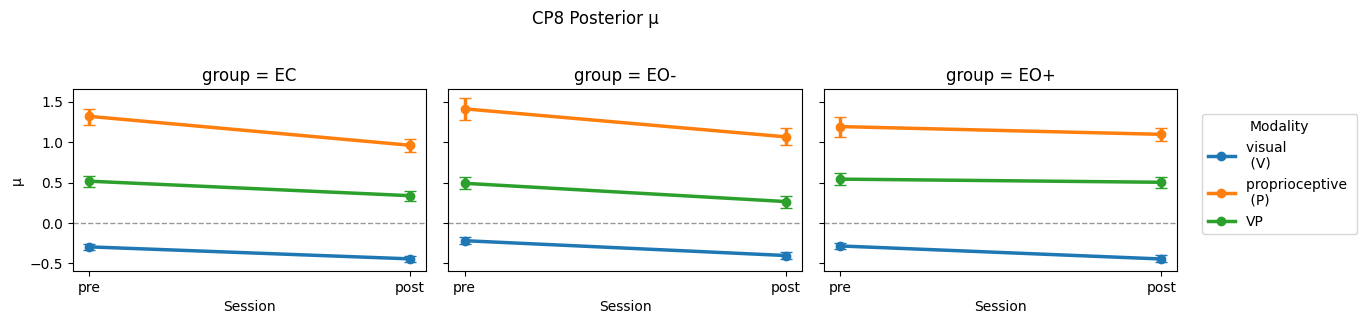

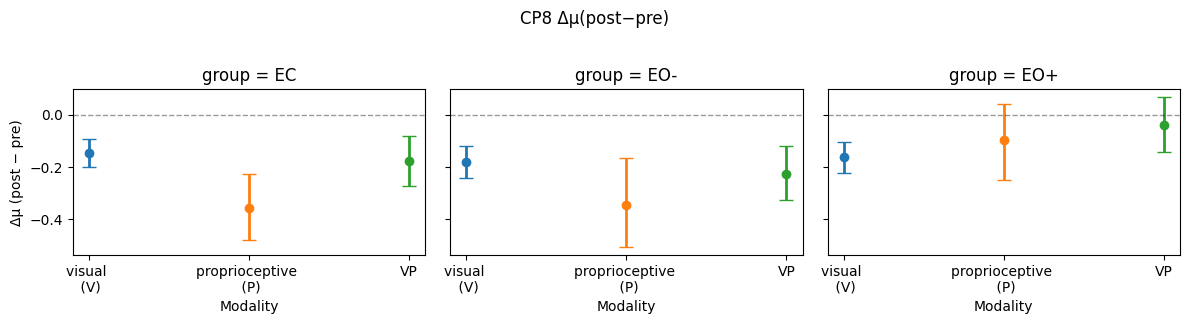

In [ ]:
cp8_mu, cp8_d = table_cp7_or_cp8_mu(level=8, prob=0.90)
plot_cp7_or_cp8_mu(8, cp8_mu)
plot_cp7_or_cp8_mu_delta(8, cp8_d)

In [5]:
# ---------- Cell 1: imports & shared config (variance viz) ----------
from pathlib import Path
import json
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt

# Paths
RES_DIR = Path("./results")

# Plot palette (same order you used for μ)
PAL = {
    "visual":        "#1f77b4",
    "proprioceptive":"#ff7f0e",
    "openloop":      "#2ca02c",
}

# Display order (match your figures)
MOD_ORDER  = ["visual", "proprioceptive", "openloop"]
SESS_ORDER = ["pre", "post1"]
GRP_ORDER  = ["EC", "EO-", "EO+"]

def _load_cp(level:int):
    mdir = RES_DIR / f"CP{level}"
    idata = az.from_netcdf(mdir / "posterior.nc")
    meta  = json.loads((mdir / "meta.json").read_text())
    return idata, meta

def _title_for(level:int) -> str:
    return f"CP{level}"

In [6]:
# Cell 2 — helpers for σ

def _tokens_from_meta(meta):
    lab = meta["labels"]
    return dict(
        s_levels=list(lab["session"]),
        m_levels=list(lab["modality"]),
        g_levels=list(lab["group"]),
    )

def _make_sigma_colnames(level:int, tokens:dict):
    """
    Recreate σ-design column names for CP level:
      CP4: S + M + S*M
      CP7: S + M + G + S*M + S*G + M*G
      CP8: CP7 + S*M*G
    """
    S = [f"s@{s}" for s in tokens["s_levels"][1:]]
    M = [f"m@{m}" for m in tokens["m_levels"][1:]]
    G = [f"g@{g}" for g in tokens["g_levels"][1:]]

    SM = [f"{a}*{b}" for a in S for b in M]
    SG = [f"{a}*{b}" for a in S for b in G]
    MG = [f"{a}*{b}" for a in M for b in G]
    SMG = [f"{s}*{m}*{g}" for s in S for m in M for g in G]

    if level == 4:
        cols = S + M + SM
    elif level == 7:
        cols = S + M + G + SM + SG + MG
    elif level == 8:
        cols = S + M + G + SM + SG + MG + SMG
    else:
        raise ValueError("This visual is intended for CP4, CP7, or CP8.")
    return cols

def _row_for_cell_sigma(beta_names, tokens, sess=None, mod=None, grp=None):
    x = np.zeros(len(beta_names), dtype=float)

    def on(name):
        try:
            j = beta_names.index(name); x[j] = 1.0
        except ValueError:
            pass

    # main effects (non-baseline only)
    if sess is not None and sess in tokens["s_levels"][1:]:
        on(f"s@{sess}")
    if mod is not None and mod in tokens["m_levels"][1:]:
        on(f"m@{mod}")
    if grp is not None and grp in tokens["g_levels"][1:]:
        on(f"g@{grp}")

    # 2-way
    if sess in tokens["s_levels"][1:] and mod in tokens["m_levels"][1:]:
        on(f"s@{sess}*m@{mod}")
    if sess in tokens["s_levels"][1:] and grp in tokens["g_levels"][1:]:
        on(f"s@{sess}*g@{grp}")
    if mod in tokens["m_levels"][1:] and grp in tokens["g_levels"][1:]:
        on(f"m@{mod}*g@{grp}")

    # 3-way
    if (sess in tokens["s_levels"][1:]
        and mod in tokens["m_levels"][1:]
        and grp in tokens["g_levels"][1:]):
        on(f"s@{sess}*m@{mod}*g@{grp}")

    return x

def posterior_sigma_draws_cell(idata, meta, level:int, sess, mod=None, grp=None):
    """
    Return posterior draws of σ for the requested cell.
    Supports:
      - hetero: sigma0 + X_sigma * gamma_sig  (sigma = exp(log_sigma))
      - homo: scalar 'sigma'
    Also supports Kσ=0 (intercept-only log-σ).
    """
    post = idata.posterior

    # Heteroscedastic path
    if "sigma0" in post and "gamma_sig" in post:
        s0 = post["sigma0"].values.reshape(-1)              # (S,)
        G  = post["gamma_sig"].values
        G  = G.reshape(-1, G.shape[-1])                     # (S, Kσ)
        Ksig = G.shape[-1]

        if Ksig == 0:
            return np.exp(s0)

        # recover σ column names
        beta_names_sig = meta.get("beta_names_sigma", None)
        toks = meta.get("tokens", None)
        if toks is None:
            toks = _tokens_from_meta(meta)

        if not beta_names_sig:
            beta_names_sig = _make_sigma_colnames(level, toks)

        xrow = _row_for_cell_sigma(beta_names_sig, toks, sess=sess, mod=mod, grp=grp)
        if xrow.shape[0] != Ksig:
            raise ValueError(f"σ design length {xrow.shape[0]} != Kσ ({Ksig}).")
        log_sigma = s0 + G @ xrow
        return np.exp(log_sigma)

    # Homoskedastic fallback
    if "sigma" in post and post["sigma"].ndim == 2:
        return post["sigma"].values.reshape(-1)

    raise KeyError("Posterior lacks ('sigma0','gamma_sig') and scalar 'sigma'.")

def _hdi(x, prob=0.95):
    lo, hi = az.hdi(x, hdi_prob=prob)
    return float(lo), float(hi)

def summarize_sigma(draws: np.ndarray, prob=0.95):
    lo, hi = _hdi(draws, prob)
    return dict(mean=float(draws.mean()), hdi_low=lo, hdi_high=hi, sd=float(draws.std()))

# -------- tables

def table_cp4_sigma(prob=0.95):
    level = 4
    idata, meta = _load_cp(level)
    sess_lvls = [s.lower() for s in meta["labels"]["session"]]
    mod_lvls  = [m.lower() for m in meta["labels"]["modality"]]
    ses  = [s for s in SESS_ORDER if s in sess_lvls]
    mods = [m for m in MOD_ORDER if m in mod_lvls]

    rows = []
    for s in ses:
        for m in mods:
            sig = posterior_sigma_draws_cell(idata, meta, level, sess=s, mod=m, grp=None)
            rows.append(dict(session=s, modality=m, **summarize_sigma(sig, prob)))
    df = pd.DataFrame(rows)

    drows = []
    for m in mods:
        pre  = df[(df.session=="pre") & (df.modality==m)].iloc[0]
        post = df[(df.session=="post1") & (df.modality==m)].iloc[0]
        drows.append(dict(
            modality=m,
            mean=float(post["mean"]-pre["mean"]),
            hdi_low=float((post["hdi_low"]-pre["hdi_high"])),   # conservative diff band
            hdi_high=float((post["hdi_high"]-pre["hdi_low"]))
        ))
    ddf = pd.DataFrame(drows)
    return df, ddf

def table_cp7_or_cp8_sigma(level:int, prob=0.95):
    assert level in (7,8)
    idata, meta = _load_cp(level)
    sess_lvls = [s.lower() for s in meta["labels"]["session"]]
    mod_lvls  = [m.lower() for m in meta["labels"]["modality"]]
    grp_lvls  = list(meta["labels"]["group"])

    ses  = [s for s in SESS_ORDER if s in sess_lvls]
    mods = [m for m in MOD_ORDER if m in mod_lvls]
    grps = [g for g in GRP_ORDER if g in grp_lvls]

    rows = []
    for g in grps:
        for s in ses:
            for m in mods:
                sig = posterior_sigma_draws_cell(idata, meta, level, sess=s, mod=m, grp=g)
                rows.append(dict(group=g, session=s, modality=m, **summarize_sigma(sig, prob)))
    df = pd.DataFrame(rows)

    drows = []
    for g in grps:
        for m in mods:
            pre  = df[(df.group==g)&(df.session=="pre")  &(df.modality==m)].iloc[0]
            post = df[(df.group==g)&(df.session=="post1")&(df.modality==m)].iloc[0]
            drows.append(dict(
                group=g, modality=m,
                mean=float(post["mean"]-pre["mean"]),
                hdi_low=float(post["hdi_low"]-pre["hdi_high"]),
                hdi_high=float(post["hdi_high"]-pre["hdi_low"]),
            ))
    ddf = pd.DataFrame(drows)
    return df, ddf

# -------- Display name mapping (same as in mean functions) --------
def _display_name(name: str) -> str:
    """Map internal names to display names."""
    mapping = {
        "openloop": "VP",
        "visual": "visual \n (V)",
        "proprioceptive": "proprioceptive \n (P)",
        "post1": "post"
    }
    return mapping.get(name, name)

# -------- plots

def plot_cp4_sigma(df_sigma: pd.DataFrame):
    plt.figure(figsize=(10,3.0))
    for m in MOD_ORDER:
        if m not in df_sigma.modality.unique(): continue
        sub = df_sigma[df_sigma.modality==m].set_index("session").loc[SESS_ORDER]
        display_sessions = [_display_name(s) for s in SESS_ORDER]
        plt.plot(display_sessions, sub["mean"], marker="o", lw=3, color=PAL[m], label=_display_name(m))
        plt.errorbar(display_sessions, sub["mean"],
                     yerr=[sub["mean"]-sub["hdi_low"], sub["hdi_high"]-sub["mean"]],
                     fmt="none", lw=1.5, color=PAL[m], capsize=4)
    plt.axhline(0, ls="--", c="k", lw=1, alpha=0.4)
    plt.xlabel("Session"); plt.ylabel("σ")
    plt.title("CP4 — Posterior σ by Modality × Session")
    plt.legend(title="Modality", loc='best'); plt.tight_layout(); plt.show()

def plot_cp4_sigma_delta(df_delta: pd.DataFrame):
    xs = np.arange(len(df_delta))
    plt.figure(figsize=(10,3.0))
    for i, (m, row) in enumerate(df_delta.set_index("modality").loc[MOD_ORDER].iterrows()):
        y = row["mean"]
        lo, hi = row["hdi_low"], row["hdi_high"]
        plt.errorbar(i, y, yerr=[[y-lo],[hi-y]], fmt="o", ms=6, lw=2, capsize=5, color=PAL[m], label=m)
    plt.axhline(0, ls="--", c="k", lw=1, alpha=0.4)
    display_mods = [_display_name(m) for m in MOD_ORDER]
    plt.xticks(xs, display_mods); plt.ylabel("Δσ(post − pre)")
    plt.title("CP4 — Δσ(post−pre) by Modality")
    plt.tight_layout(); plt.show()

def plot_cp7_or_cp8_sigma(level:int, df_sigma: pd.DataFrame):
    grps = [g for g in GRP_ORDER if g in df_sigma["group"].unique()]
    fig, axes = plt.subplots(1, len(grps), figsize=(12,3.0), sharey=True)
    if len(grps)==1: axes=[axes]
    
    display_sessions = [_display_name(s) for s in SESS_ORDER]
    
    for ax, g in zip(axes, grps):
        sub = df_sigma[df_sigma.group==g]
        for m in MOD_ORDER:
            if m not in sub.modality.unique(): continue
            ss = sub[sub.modality==m].set_index("session").loc[SESS_ORDER]
            ax.plot(display_sessions, ss["mean"], marker="o", lw=3, color=PAL[m], label=_display_name(m))
            ax.errorbar(display_sessions, ss["mean"],
                        yerr=[ss["mean"]-ss["hdi_low"], ss["hdi_high"]-ss["mean"]],
                        fmt="none", lw=1.5, color=PAL[m], capsize=4)
        ax.set_title(f"group = {g}")
        ax.axhline(0, ls="--", c="k", lw=1, alpha=0.4)
        ax.set_xlabel("Session")
    axes[0].set_ylabel("σ")
    fig.suptitle(f"CP{level} Posterior σ", y=1.05)
    handles = [plt.Line2D([0],[0], color=PAL[m], marker="o", lw=3) for m in MOD_ORDER]
    labels = [_display_name(m) for m in MOD_ORDER]
    fig.legend(handles, labels, title="Modality", bbox_to_anchor=(1.0, 0.5), loc='center left')
    plt.tight_layout(); plt.show()

def plot_cp7_or_cp8_sigma_delta(level:int, df_delta: pd.DataFrame):
    grps = [g for g in GRP_ORDER if g in df_delta["group"].unique()]
    fig, axes = plt.subplots(1, len(grps), figsize=(12,3.0), sharey=True)
    if len(grps)==1: axes=[axes]
    
    display_mods = [_display_name(m) for m in MOD_ORDER]
    
    for ax, g in zip(axes, grps):
        sub = df_delta[df_delta.group==g].set_index("modality").loc[MOD_ORDER]
        xs = np.arange(len(sub))
        for i, (m, row) in enumerate(sub.iterrows()):
            y, lo, hi = row["mean"], row["hdi_low"], row["hdi_high"]
            ax.errorbar(i, y, yerr=[[y-lo],[hi-y]], fmt="o", ms=6, lw=2, capsize=5, color=PAL[m])
        ax.axhline(0, ls="--", c="k", lw=1, alpha=0.4)
        ax.set_title(f"group = {g}")
        ax.set_xticks(xs); ax.set_xticklabels(display_mods)
        ax.set_xlabel("Modality")
    axes[0].set_ylabel("Δσ(post − pre)")
    fig.suptitle(f"CP{level} Δσ(post−pre)", y=1.05)
    plt.tight_layout(); plt.show()


In [7]:
# # ---------- Cell 3: run the variance visuals ----------

# # CP4 (no group)
# df4_sigma, df4_delta = table_cp4_sigma(prob=0.95)
# plot_cp4_sigma(df4_sigma)
# plot_cp4_sigma_delta(df4_delta)

# # CP7
# df7_sigma, df7_delta = table_cp7_or_cp8_sigma(level=7, prob=0.95)
# plot_cp7_or_cp8_sigma(7, df7_sigma)
# plot_cp7_or_cp8_sigma_delta(7, df7_delta)

# # CP8
# df8_sigma, df8_delta = table_cp7_or_cp8_sigma(level=8, prob=0.95)
# plot_cp7_or_cp8_sigma(8, df8_sigma)
# plot_cp7_or_cp8_sigma_delta(8, df8_delta)

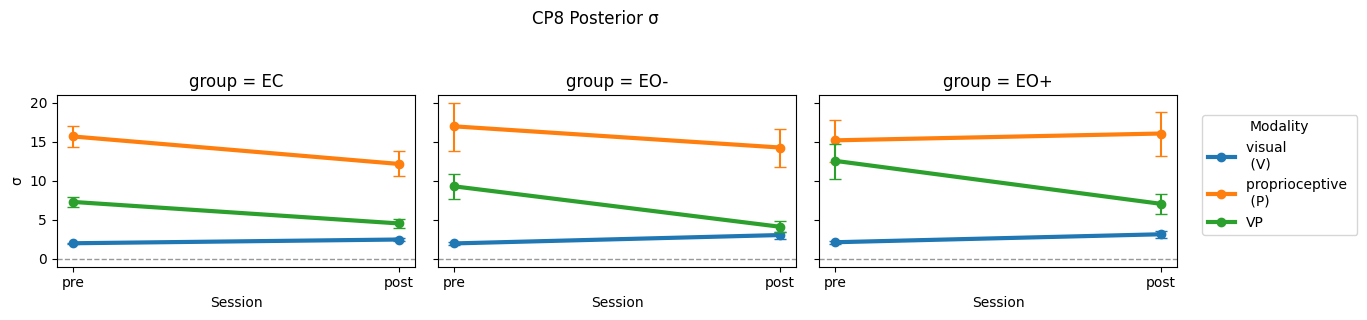

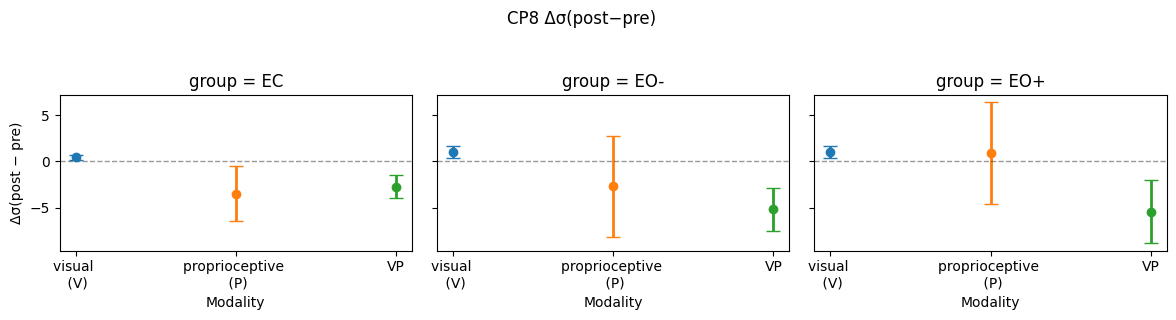

CP8, EC–proprioceptive: P(Δσ < 0 | data) = 1.000
Δσ mean = -3.521, SD = 0.782


In [8]:
# CP8
df8_sigma, df8_delta = table_cp7_or_cp8_sigma(level=8, prob=0.90)
plot_cp7_or_cp8_sigma(8, df8_sigma)
plot_cp7_or_cp8_sigma_delta(8, df8_delta)

# --- NEW: posterior probability that Δσ < 0 for EC, proprioceptive (CP8) ---
idata8, meta8 = _load_cp(8)

# draws of sigma for that cell
sig_pre  = posterior_sigma_draws_cell(idata8, meta8, level=8,
                                      sess="pre",   mod="proprioceptive", grp="EC")
sig_post = posterior_sigma_draws_cell(idata8, meta8, level=8,
                                      sess="post1", mod="proprioceptive", grp="EC")

d_sigma = sig_post - sig_pre
p_decrease = (d_sigma < 0).mean()

print(f"CP8, EC–proprioceptive: P(Δσ < 0 | data) = {p_decrease:.3f}")
print(f"Δσ mean = {d_sigma.mean():.3f}, SD = {d_sigma.std():.3f}")

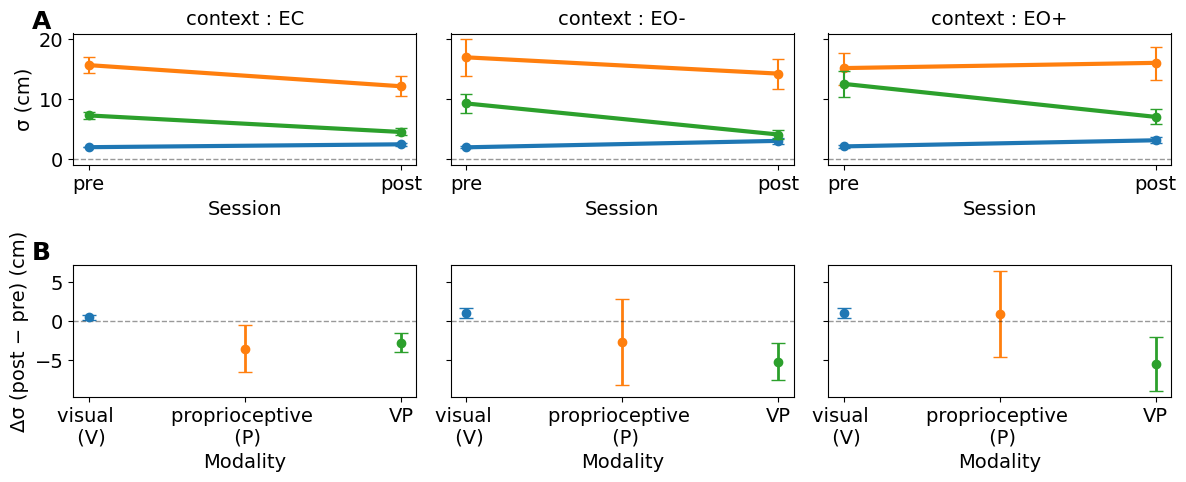

In [20]:
def plot_cp7_or_cp8_sigma_combined(level:int, df_sigma: pd.DataFrame, df_delta: pd.DataFrame):                                           
      grps = [g for g in GRP_ORDER if g in df_sigma["group"].unique()]                                                                     
                                                                                                                                           
      # Create 2 rows: top for sigma, bottom for delta                                                                                     
      fig, axes = plt.subplots(2, len(grps), figsize=(12, 5), sharey='row')                                                                
                                                                                                                                           
      display_sessions = [_display_name(s) for s in SESS_ORDER]                                                                            
      display_mods = [_display_name(m) for m in MOD_ORDER]                                                                                 
                                                                                                                                           
      # Top row: sigma                                                                                                                     
      for col_idx, g in enumerate(grps):                                                                                                   
          ax = axes[0, col_idx] if len(grps) > 1 else axes[0]                                                                              
          sub = df_sigma[df_sigma.group==g]                                                                                                
          for m in MOD_ORDER:                                                                                                              
              if m not in sub.modality.unique(): continue                                                                                  
              ss = sub[sub.modality==m].set_index("session").loc[SESS_ORDER]                                                               
              ax.plot(display_sessions, ss["mean"], marker="o", lw=3, color=PAL[m], label=_display_name(m))                                
              ax.errorbar(display_sessions, ss["mean"],                                                                                    
                          yerr=[ss["mean"]-ss["hdi_low"], ss["hdi_high"]-ss["mean"]],                                                      
                          fmt="none", lw=1.5, color=PAL[m], capsize=4)                                                                     
          ax.set_title(f"context : {g}", fontsize=14)
          ax.axhline(0, ls="--", c="k", lw=1, alpha=0.4)                                                                                   
          ax.set_xlabel("Session", fontsize=14)
          ax.tick_params(axis="both", labelsize=14)
          if col_idx == 0:                                                                                                                 
              ax.set_ylabel("σ (cm)", fontsize=14)
              ax.text(-0.12, 1.18, "A", transform=ax.transAxes,
                      fontsize=18, fontweight="bold", va="top", ha="left")
                                                                                                                                           
      # Bottom row: delta                                                                                                                  
      for col_idx, g in enumerate(grps):                                                                                                   
          ax = axes[1, col_idx] if len(grps) > 1 else axes[1]                                                                              
          sub = df_delta[df_delta.group==g].set_index("modality").loc[MOD_ORDER]                                                           
          xs = np.arange(len(sub))                                                                                                         
          for i, (m, row) in enumerate(sub.iterrows()):                                                                                    
              y, lo, hi = row["mean"], row["hdi_low"], row["hdi_high"]                                                                     
              ax.errorbar(i, y, yerr=[[y-lo],[hi-y]], fmt="o", ms=6, lw=2, capsize=5, color=PAL[m])                                        
          ax.axhline(0, ls="--", c="k", lw=1, alpha=0.4)                                                                                   
          ax.set_xticks(xs); ax.set_xticklabels(display_mods, fontsize=14)
          ax.set_xlabel("Modality", fontsize=14)                                                                                                        
          ax.tick_params(axis="both", labelsize=14)
          if col_idx == 0:                                                                                                                 
              ax.set_ylabel("Δσ (post − pre) (cm)", fontsize=14)
              ax.text(-0.12, 1.18, "B", transform=ax.transAxes,
                      fontsize=18, fontweight="bold", va="top", ha="left")
                                                                                                                                           
      # Legend                                                                                                                             
    #   handles = [plt.Line2D([0],[0], color=PAL[m], marker="o", lw=3) for m in MOD_ORDER]                                                   
    #   labels = [_display_name(m) for m in MOD_ORDER]                                                                                       
    #   fig.legend(handles, labels, title="Modality", bbox_to_anchor=(1.0, 0.5), loc='center left')                                          
                                                                                                                                           
      plt.tight_layout()                                                                                                                   
      plt.show()                                                                                                                           
                                                                                                                                  
plot_cp7_or_cp8_sigma_combined(8, df8_sigma, df8_delta)

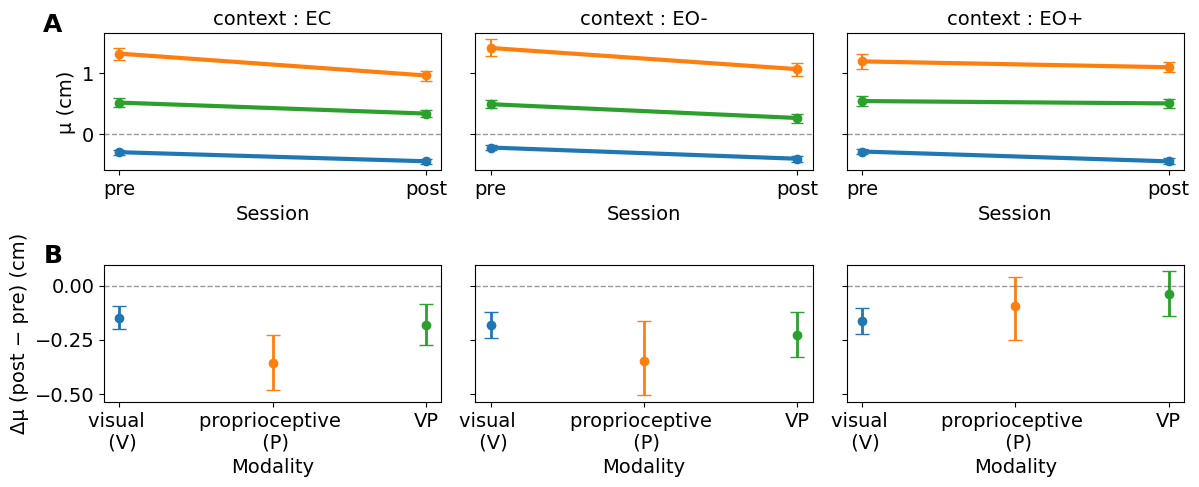

In [21]:
def plot_cp7_or_cp8_mu_combined(level:int, df_mu: pd.DataFrame, df_delta: pd.DataFrame):
    grps = [g for g in GRP_ORDER if g in df_mu["group"].unique()]

    # 2 rows: top for μ by session, bottom for Δμ
    fig, axes = plt.subplots(2, len(grps), figsize=(12, 5), sharey='row')

    display_sessions = [_display_name(s) for s in SESS_ORDER]
    display_mods = [_display_name(m) for m in MOD_ORDER]

    # Top row: μ by session
    for col_idx, g in enumerate(grps):
        ax = axes[0, col_idx] if len(grps) > 1 else axes[0]
        sub = df_mu[df_mu.group == g]
        for m in MOD_ORDER:
            if m not in sub.modality.unique(): continue
            ss = sub[sub.modality == m].set_index("session").loc[SESS_ORDER]
            ax.plot(display_sessions, ss["mean"], marker="o", lw=3, color=PAL[m], label=_display_name(m))
            ax.errorbar(display_sessions, ss["mean"],
                        yerr=[ss["mean"] - ss["hdi_low"], ss["hdi_high"] - ss["mean"]],
                        fmt="none", lw=1.5, color=PAL[m], capsize=4)
        ax.set_title(f"context : {g}", fontsize=14)
        ax.axhline(0, ls="--", c="k", lw=1, alpha=0.4)
        ax.set_xlabel("Session", fontsize=14)
        ax.tick_params(axis="both", labelsize=14)
        if col_idx == 0:
            ax.set_ylabel("μ (cm)", fontsize=14)
            ax.text(-0.18, 1.15, "A", transform=ax.transAxes,
                    fontsize=18, fontweight="bold", va="top", ha="left")

    # Bottom row: Δμ (post − pre)
    for col_idx, g in enumerate(grps):
        ax = axes[1, col_idx] if len(grps) > 1 else axes[1]
        sub = df_delta[df_delta.group == g].set_index("modality").loc[MOD_ORDER]
        xs = np.arange(len(sub))
        for i, (m, row) in enumerate(sub.iterrows()):
            y, lo, hi = row["mean"], row["hdi_low"], row["hdi_high"]
            ax.errorbar(i, y, yerr=[[y - lo], [hi - y]], fmt="o", ms=6, lw=2, capsize=5, color=PAL[m])
        ax.axhline(0, ls="--", c="k", lw=1, alpha=0.4)
        ax.set_xticks(xs); ax.set_xticklabels(display_mods, fontsize=14)
        ax.set_xlabel("Modality", fontsize=14)
        ax.tick_params(axis="both", labelsize=14)
        if col_idx == 0:
            ax.set_ylabel("Δμ (post − pre) (cm)", fontsize=14)
            ax.text(-0.18, 1.15, "B", transform=ax.transAxes,
                    fontsize=18, fontweight="bold", va="top", ha="left")

    plt.tight_layout()
    plt.show()

cp8_mu, cp8_d = table_cp7_or_cp8_mu(level=8, prob=0.90)
plot_cp7_or_cp8_mu_combined(8, cp8_mu, cp8_d)